In [1]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.cluster import DBSCAN
from sklearn.neighbors import BallTree
import warnings
warnings.filterwarnings('ignore')

# Paths
RAW_DATA_DIR = os.path.expanduser("/home/du2/22CS30034/karan/GIS/calgary_smart_campus")
PROJECT_DIR = os.path.expanduser("/home/du2/22CS30034/karan/GIS/calgary_smart_campus")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
EARTH_RADIUS_METERS = 6371008.8

def get_safe_filename(title):
    return "".join([c if c.isalnum() else "_" for c in title]).replace("__", "_").lower()

In [2]:
def parse_path_data():
    path_files = glob.glob(os.path.join(RAW_DATA_DIR, "*Paths*.tab"))
    if not path_files:
        return pd.DataFrame()
        
    raw_df = pd.read_csv(path_files[0], sep="\t", low_memory=False)
    
    # Extract specific kinematic and environmental path features
    df_path = pd.DataFrame({
        "timestamp": pd.to_datetime(raw_df["Loct"], format="%d-%b-%Y %I:%M:%S %p", errors="coerce"),
        "lat": pd.to_numeric(raw_df["Lat"], errors="coerce"),
        "lon": pd.to_numeric(raw_df["Lon"], errors="coerce"),
        "building": raw_df["Building_Name"].astype(str) if "Building_Name" in raw_df.columns else "Unknown",
        "speed": pd.to_numeric(raw_df["Speed"], errors="coerce"),
        "temp_c": pd.to_numeric(raw_df["Mean_Temp_C"], errors="coerce"),
        "snow_cm": pd.to_numeric(raw_df["Snow_cm"], errors="coerce"),
        "term": raw_df["Academic_Day"].astype(str) if "Academic_Day" in raw_df.columns else "Unknown"
    }).dropna(subset=["timestamp", "lat", "lon"])
    
    df_path["epoch_sec"] = df_path["timestamp"].astype("int64") // 10**9
    df_path["hour"] = df_path["timestamp"].dt.hour
    
    # Spatial filter and strict Outdoor/Unknown removal
    df_path = df_path[(df_path["lat"].between(51.070, 51.090)) & (df_path["lon"].between(-114.150, -114.110))]
    df_path = df_path[~df_path["building"].isin(["Outdoors", "Unknown", "BETWEEN TERMS"])].copy()

    return df_path

df_path = parse_path_data()
print(f"Loaded {len(df_path)} filtered Path Points focused on building-transit nodes.")

Loaded 25921 filtered Path Points focused on building-transit nodes.


In [3]:
def plot_ground_truth(df, title):
    if df.empty: return
    unique_buildings = [b for b in df["building"].unique() if str(b) != "nan"]
    fig, ax = plt.subplots(figsize=(10, 8))
    
    color_array = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, max(len(unique_buildings), 1)))
    np.random.seed(42)
    np.random.shuffle(color_array)
    color_dict = {b: color_array[i] for i, b in enumerate(unique_buildings)}

    for b in unique_buildings:
        mask = df["building"] == b
        ax.scatter(df.loc[mask, "lon"], df.loc[mask, "lat"], c=[color_dict[b]], s=5, alpha=0.6)

    ax.set_title(f"Ground Truth: {title} ({len(unique_buildings)} Building Nodes)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

    handles = [mpatches.Patch(color=color_dict[b], label=b[:20]) for b in sorted(unique_buildings)[:30]]
    if len(unique_buildings) > 30: handles.append(mpatches.Patch(color="white", label="..."))

    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=8)
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"0_ground_truth_path_{get_safe_filename(title)}.png"), dpi=300, bbox_inches="tight")
    plt.show()

def run_kde_and_plot(df, title):
    if df.empty or len(df) < 10: return
    fig, ax = plt.subplots(figsize=(10, 8))
    
    x, y = df["lon"].values, df["lat"].values
    kde = gaussian_kde(np.vstack([x, y]))
    xi, yi = np.mgrid[x.min():x.max():150j, y.min():y.max():150j]
    zi = kde(np.vstack([xi.flatten(), yi.flatten()])).reshape(xi.shape)
    
    contour = ax.contourf(xi, yi, zi, levels=20, cmap="inferno")
    ax.set_title(f"KDE Flow Density: {title}")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    cbar = fig.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Path Node Intensity', rotation=270, labelpad=15)
    
    plt.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, f"3_kde_path_{get_safe_filename(title)}.png"), dpi=300)
    plt.show()

def run_dbscan_and_plot(df, title, eps_m=15.0, min_pts=40):
    if df.empty: return
    coords = np.radians(df[["lat", "lon"]].values)
    db = DBSCAN(eps=eps_m / EARTH_RADIUS_METERS, min_samples=min_pts, metric="haversine")
    df["cluster"] = db.fit_predict(coords)
    
    mask = df["cluster"] != -1
    unique_clusters = sorted(df.loc[mask, "cluster"].unique())

    fig, ax = plt.subplots(figsize=(10, 8))
    color_array = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, max(len(unique_clusters), 1)))
    np.random.seed(42)
    np.random.shuffle(color_array)
    color_dict = {c: color_array[i] for i, c in enumerate(unique_clusters)}

    ax.scatter(df.loc[~mask, "lon"], df.loc[~mask, "lat"], c="lightgrey", s=2, alpha=0.3)
    if not df[mask].empty:
        df.loc[mask, "plot_color"] = df.loc[mask, "cluster"].map(color_dict)
        ax.scatter(df.loc[mask, "lon"], df.loc[mask, "lat"], c=list(df.loc[mask, "plot_color"]), s=10)
    
    ax.set_title(f"DBSCAN Transit Bottlenecks: {title} ({len(unique_clusters)} Hubs)")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    
    handles = [mpatches.Patch(color="lightgrey", label="Noise (-1)")]
    for c in unique_clusters[:30]: handles.append(mpatches.Patch(color=color_dict[c], label=f"Hub {c}"))
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=5, fontsize=8)
    plt.tight_layout()
    plt.show()

--- Establishing Path Ground Truth & Baseline Algorithms ---


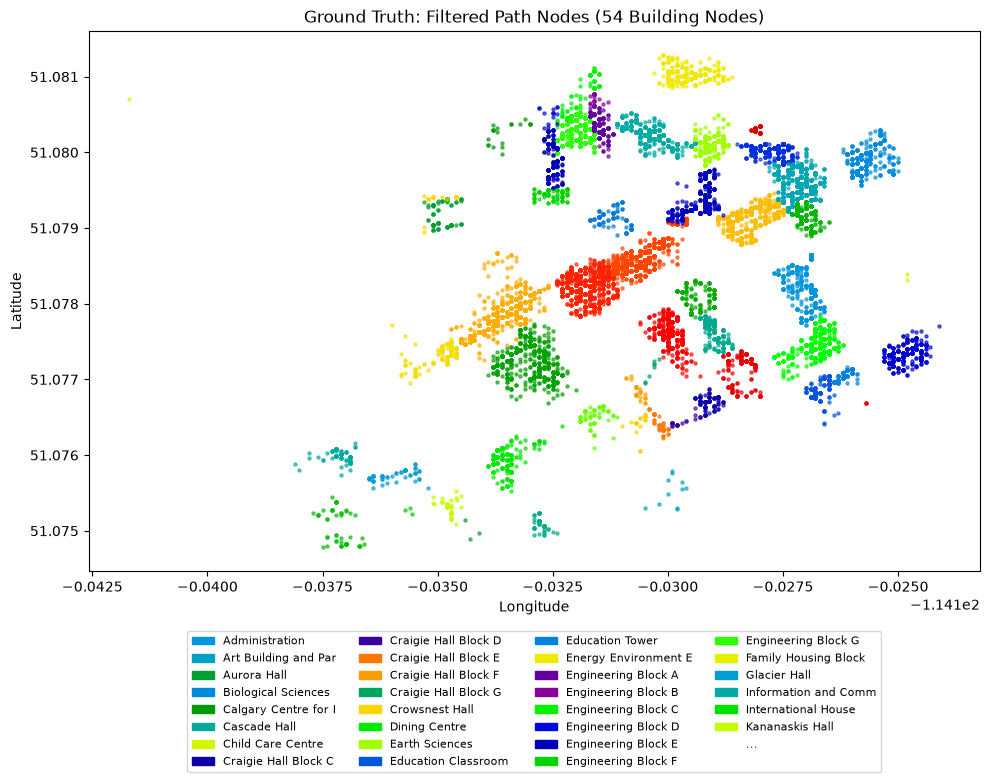

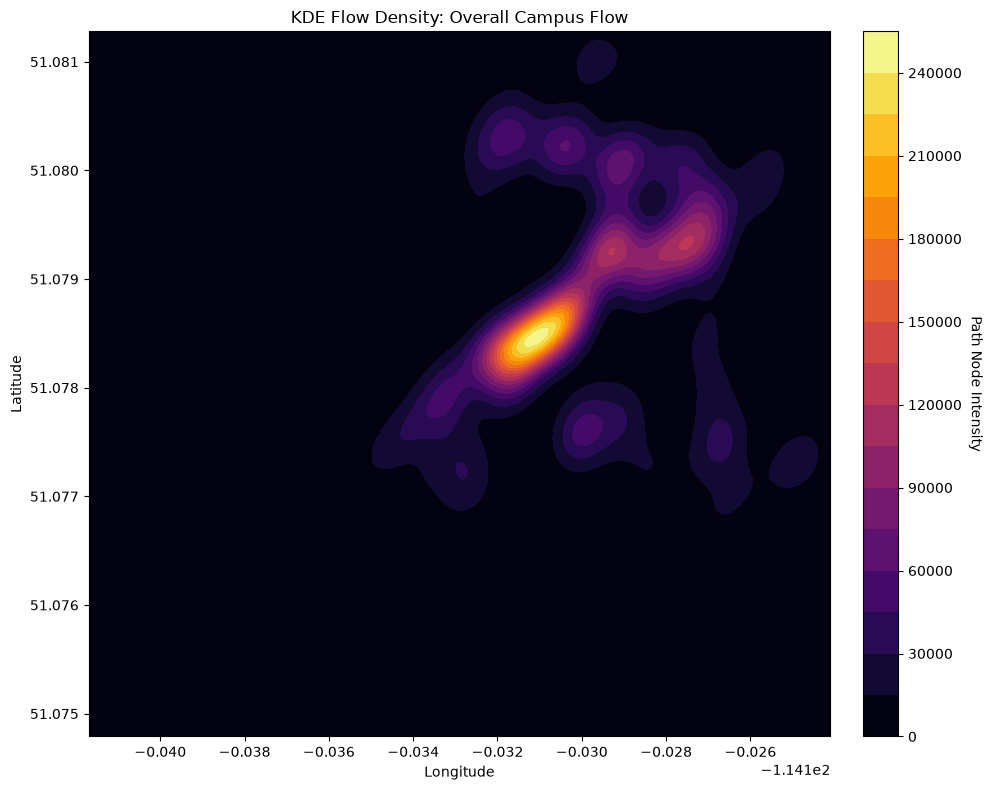

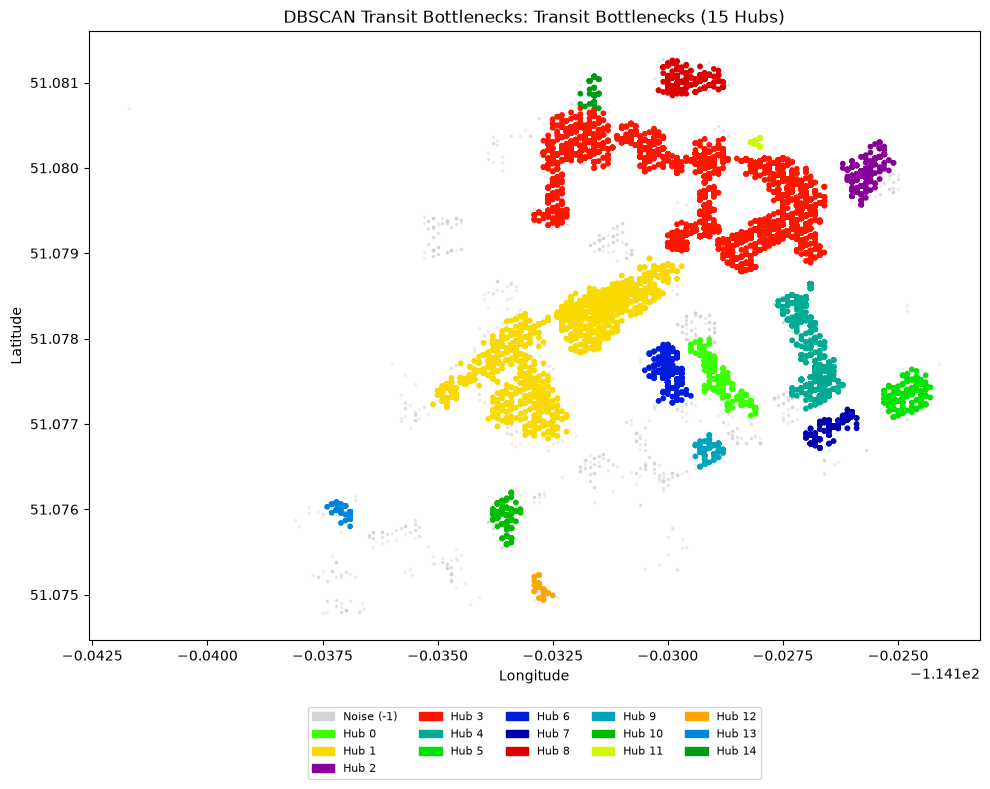

In [4]:
print("--- Establishing Path Ground Truth & Baseline Algorithms ---")
plot_ground_truth(df_path, "Filtered Path Nodes")

# Run KDE to see where the heaviest walking density occurs near buildings
run_kde_and_plot(df_path, "Overall Campus Flow")

# Run DBSCAN to identify specific geographic bottlenecks/congested nodes
run_dbscan_and_plot(df_path, "Transit Bottlenecks", eps_m=15.0, min_pts=40)

--- Inferring Fast Transit vs. Slow Congestion ---


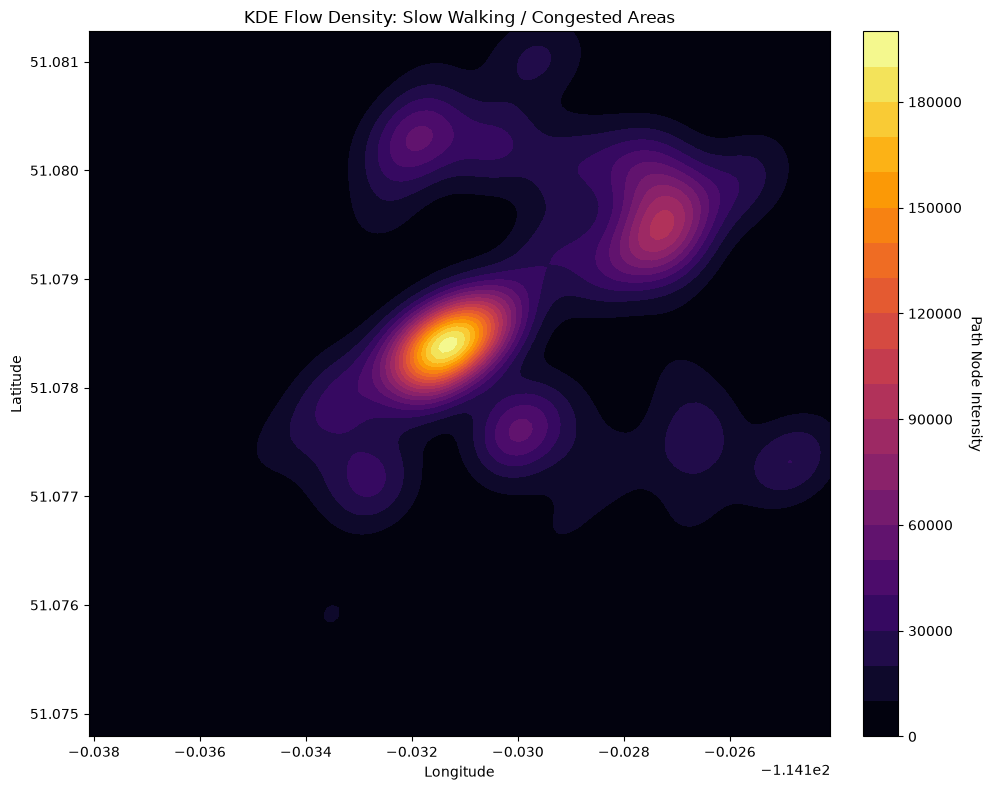

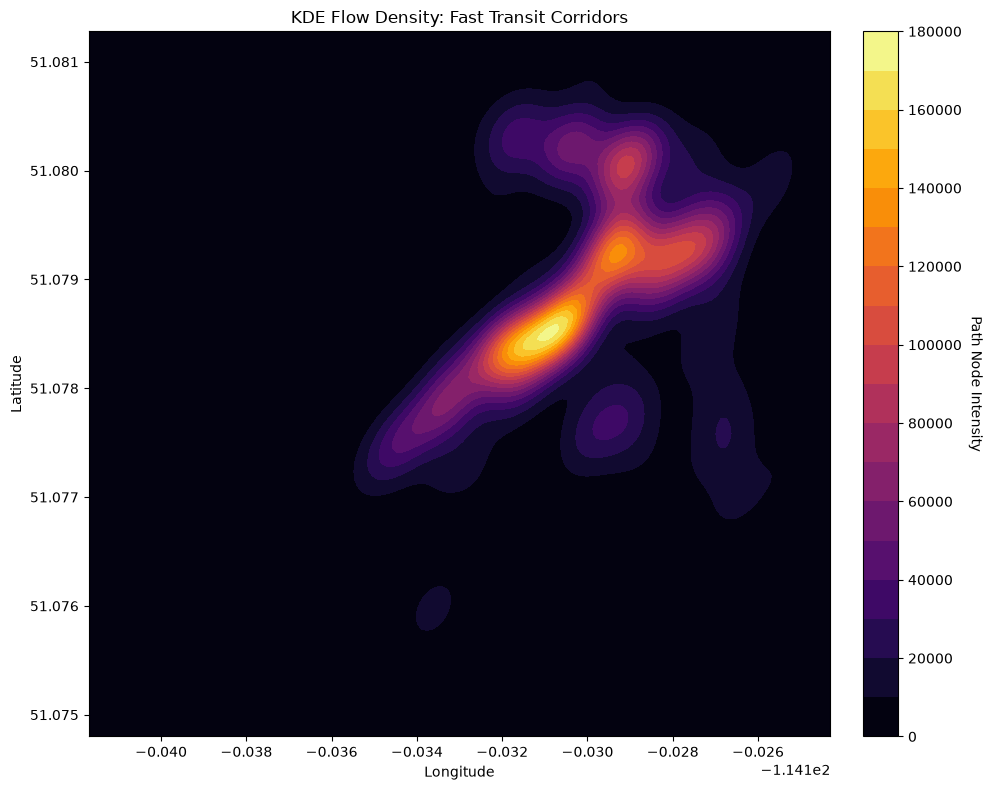

In [5]:
print("--- Inferring Fast Transit vs. Slow Congestion ---")
# Assuming speed is in meters/second or similar unit; adjust thresholds based on your data distribution
median_speed = df_path["speed"].median()

slow_paths = df_path[df_path["speed"] < median_speed * 0.5]
fast_paths = df_path[df_path["speed"] > median_speed * 1.5]

run_kde_and_plot(slow_paths, "Slow Walking / Congested Areas")
run_kde_and_plot(fast_paths, "Fast Transit Corridors")

--- Inferring Environmental Flow Adjustments ---


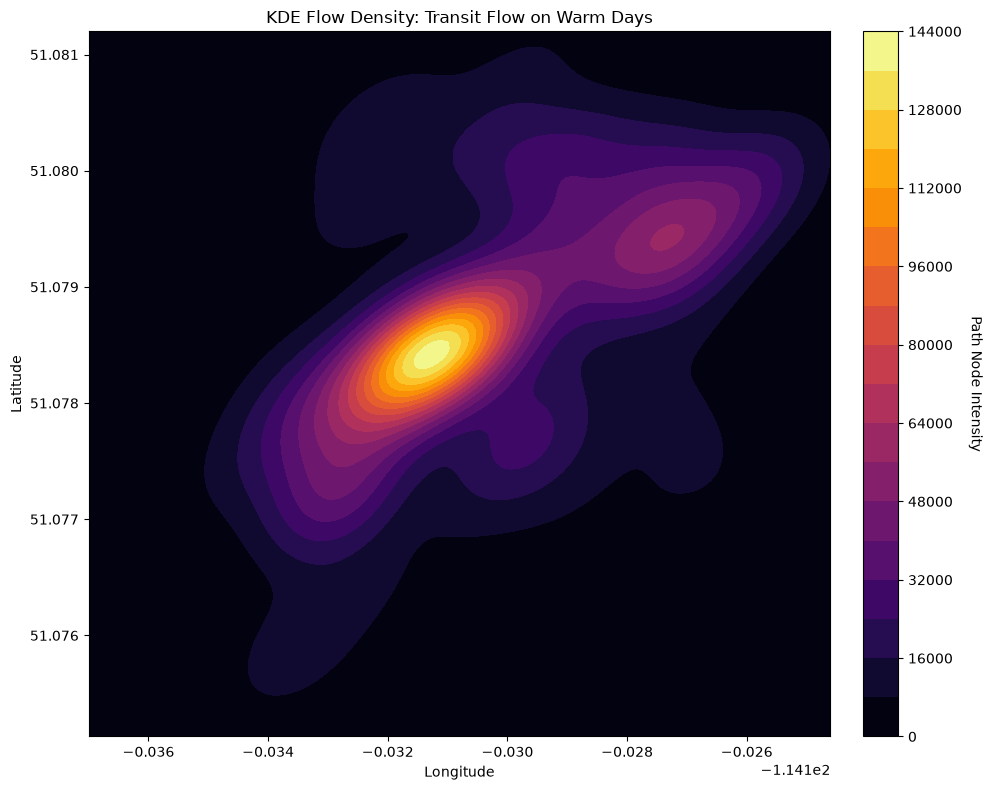

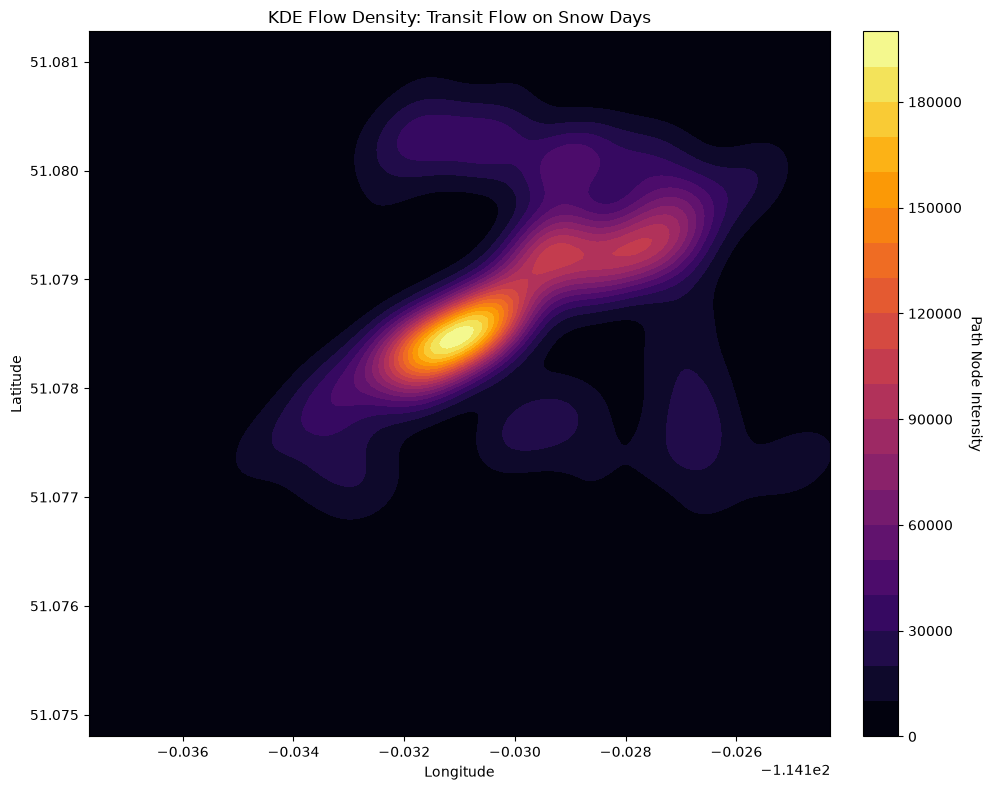

In [6]:
print("--- Inferring Environmental Flow Adjustments ---")
warm_paths = df_path[df_path["temp_c"] > 15]
snow_paths = df_path[df_path["snow_cm"] > 5]

run_kde_and_plot(warm_paths, "Transit Flow on Warm Days")
run_kde_and_plot(snow_paths, "Transit Flow on Snow Days")

--- Inferring Time-of-Day Transit Corridors ---


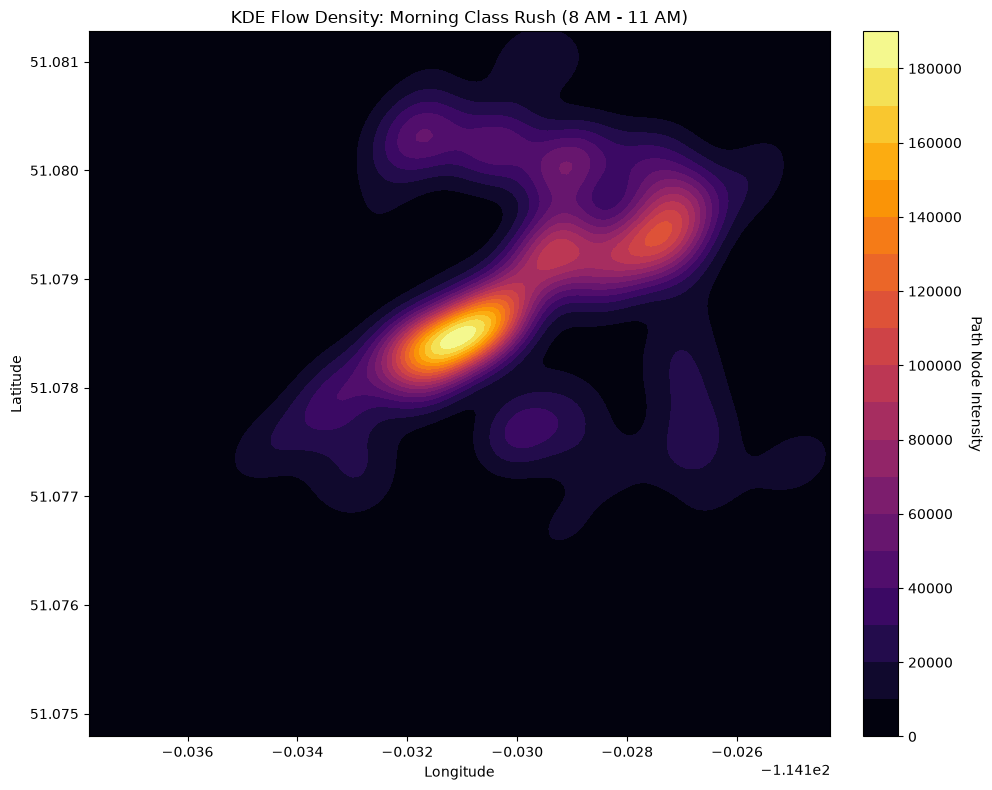

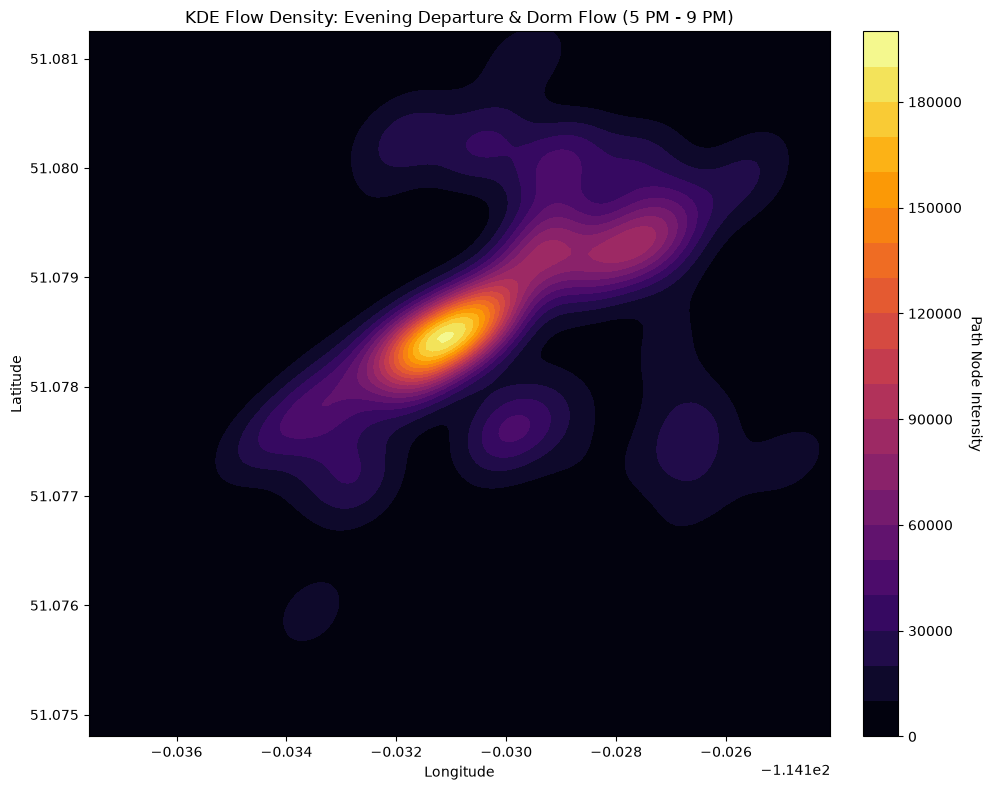

In [7]:
print("--- Inferring Time-of-Day Transit Corridors ---")
morning_transit = df_path[(df_path["hour"] >= 8) & (df_path["hour"] <= 11)]
evening_transit = df_path[(df_path["hour"] >= 17) & (df_path["hour"] <= 21)]

run_kde_and_plot(morning_transit, "Morning Class Rush (8 AM - 11 AM)")
run_kde_and_plot(evening_transit, "Evening Departure & Dorm Flow (5 PM - 9 PM)")